# Day2: Pandas 탐색적 자료 분석

## 학습 내용
1. `Matplotlib`을 이용한 데이터 시각화
2. `seaborn`을 이용한 시각화

In [11]:
import os

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image

data_dir = "../data"

## 한글 폰트 설치
- colab: 설치 후 반드시 세션 다시 시작 실핼

In [ ]:
!sudo apt-get install -y fonts-nanum* 
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

In [ ]:
# 폰트 관련 용도
import matplotlib.font_manager as fm

# Colab, Linux
# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path).get_name()

In [ ]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = False # True 하면 기본적으로 X축, Y축 가이드 선 표시
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

## 1. matplotlib 시각화
-
    - `.plot()`
    - `.scatter()`
    - `.bar()`
    - `.hist()`
    - `.pie()`

- **< tips >** 자료 소개 
- 식당의 영수증 정보를 담고 있는 내장 데이터셋으로, 총계(total\_bill), 팁(tip), 성별(sex), 흡연 여부(smoker), 요일(day), 시간(time), 테이블 크기(size) 등의 변수(컬럼)를 포함합니다. 
- 이 데이터셋은 주로 음식값과 팁 사이의 관계를 파악하거나, 다른 요인들이 팁에 미치는 영향을 시각화하고 분석하는 데 사용됩니다. 

    - `total_bill`: 식사 총액 (달러)
    - `tip`: 팁 금액 (달러)
    - `sex`: 고객의 성별 (남성, 여성)
    - `smoker`: 흡연자 여부 (예, 아니오)
    - `day`: 요일 (월, 화, 수, 목, 금, 토, 일)
    - `time`: 시간대 (점심, 저녁)
    - `size`: 테이블에 앉은 사람 수 

filename = 'tips.csv'

In [22]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 선 그래프 (시간의 흐름/순서에 따른 변화) (.plot())

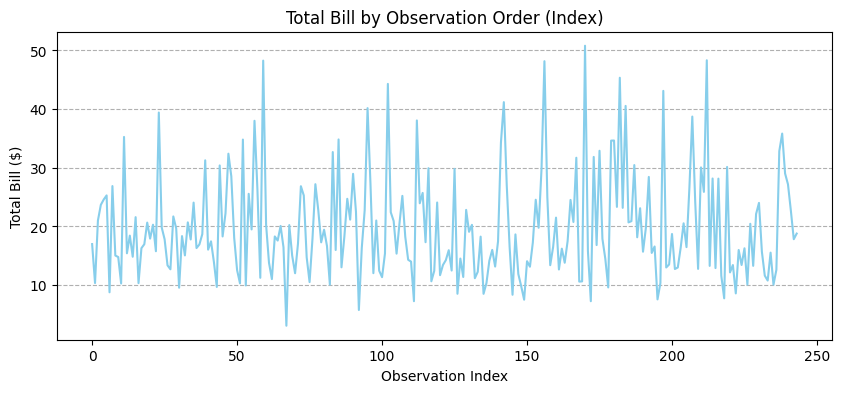

'  \n이 그래프는 시간의 흐름(또는 데이터가 기록된 순서, 즉 인덱스)에 따라 \ntotal_bill의 크기가 어떻게 변하는지를 보여줍니다. \n특별한 패턴 없이 값이 위아래로 불규칙하게 변동하는 것을 통해, \n테이블 방문 순서와 주문 금액 사이에는 명확한 관계가 없다는 것을 직관적으로 알 수 있습니다.\n'

In [ ]:
# 시간변화에 따른 데이터의 변화를 보여주는 그래프

plt.figure(figsize=(10, 4))
plt.plot(tips['total_bill'], color='skyblue')
plt.title('Total Bill by Observation Order (Index)')
plt.xlabel('Observation Index')
plt.ylabel('Total Bill ($)')
plt.grid(axis='y', linestyle='--') # X축, Y축 모두 표시될 경우에는 plt.rcParams['axes.grid'] 이 True 인지 체크하기
# plt.grid(axis='x', linestyle='-.') # X축에 -. 형태의 선 표시. 
plt.show()

'''  
이 그래프는 시간의 흐름(또는 데이터가 기록된 순서, 즉 인덱스)에 따라 
total_bill의 크기가 어떻게 변하는지를 보여줍니다. 
특별한 패턴 없이 값이 위아래로 불규칙하게 변동하는 것을 통해, 
테이블 방문 순서와 주문 금액 사이에는 명확한 관계가 없다는 것을 직관적으로 알 수 있습니다.
'''

### 산점도 (두 변수 간의 관계) (.scatter())

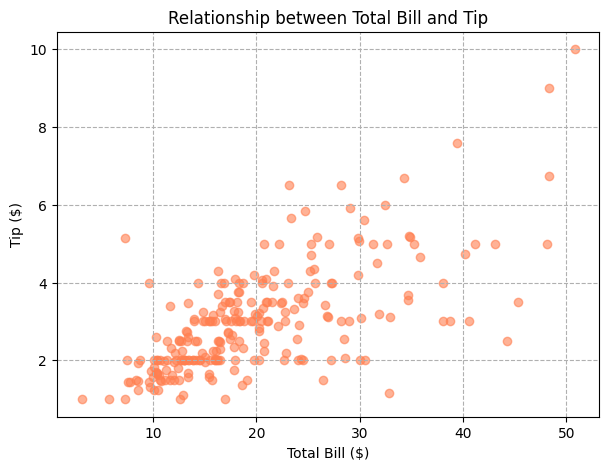

'      \n그래프의 점들이 오른쪽 위로 향하는 선형적인 패턴을 보입니다. \n이는 총 계산 금액(total_bill)이 증가할수록 팁(tip) 금액도 함께 증가하는 \n양의 상관관계가 있음을 명확하게 보여줍니다. 대부분의 데이터 포인트가 특정 영역에 밀집되어 있지만, \n가끔 높은 금액에 높은 팁을 주는 아웃라이어(이상치)도 관찰됩니다.\n'

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(x=tips['total_bill'], y=tips['tip'], alpha=0.6, color='coral') # alpha 속성은 투명도 관여
plt.title('Relationship between Total Bill and Tip')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.grid(linestyle='--')
plt.show()

'''      
그래프의 점들이 오른쪽 위로 향하는 선형적인 패턴을 보입니다. 
이는 총 계산 금액(total_bill)이 증가할수록 팁(tip) 금액도 함께 증가하는 
양의 상관관계가 있음을 명확하게 보여줍니다. 대부분의 데이터 포인트가 특정 영역에 밀집되어 있지만, 
가끔 높은 금액에 높은 팁을 주는 아웃라이어(이상치)도 관찰됩니다.
'''

### 히스토그램 (단일 변수의 분포) (.hist())

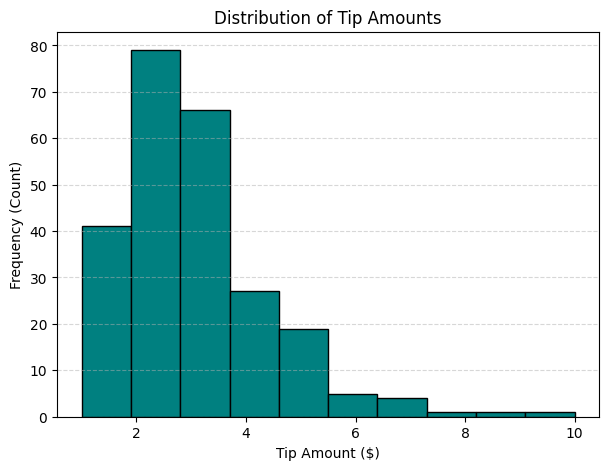

'   \n이 히스토그램은 팁 금액이 오른쪽으로 긴 꼬리를 가진 분포(Right-Skewed Distribution) 를 보임을 나타냅니다. \n즉, 대부분의 팁은 $2-$3 사이에 집중되어 있으며, $5 이상의 고액 팁은 상대적으로 매우 적습니다. \n이는 일반적인 식당 팁 패턴을 반영합니다.\n'

In [ ]:
# hist : 데이터 분포도
plt.figure(figsize=(7, 5))
plt.hist(tips["tip"], bins=10, edgecolor='black', color='teal') # bins 는 데이터를 몇 개의 구간으로 나눠서 빈도수를 셀지를 결정하는 속성
plt.title('Distribution of Tip Amounts')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency (Count)')
plt.grid(axis='y', linestyle='--', alpha = 0.5)
plt.show()

'''   
이 히스토그램은 팁 금액이 오른쪽으로 긴 꼬리를 가진 분포(Right-Skewed Distribution) 를 보임을 나타냅니다. 
즉, 대부분의 팁은 $2-$3 사이에 집중되어 있으며, $5 이상의 고액 팁은 상대적으로 매우 적습니다. 
이는 일반적인 식당 팁 패턴을 반영합니다.
'''

### 사분위수 범위 (.boxplot())

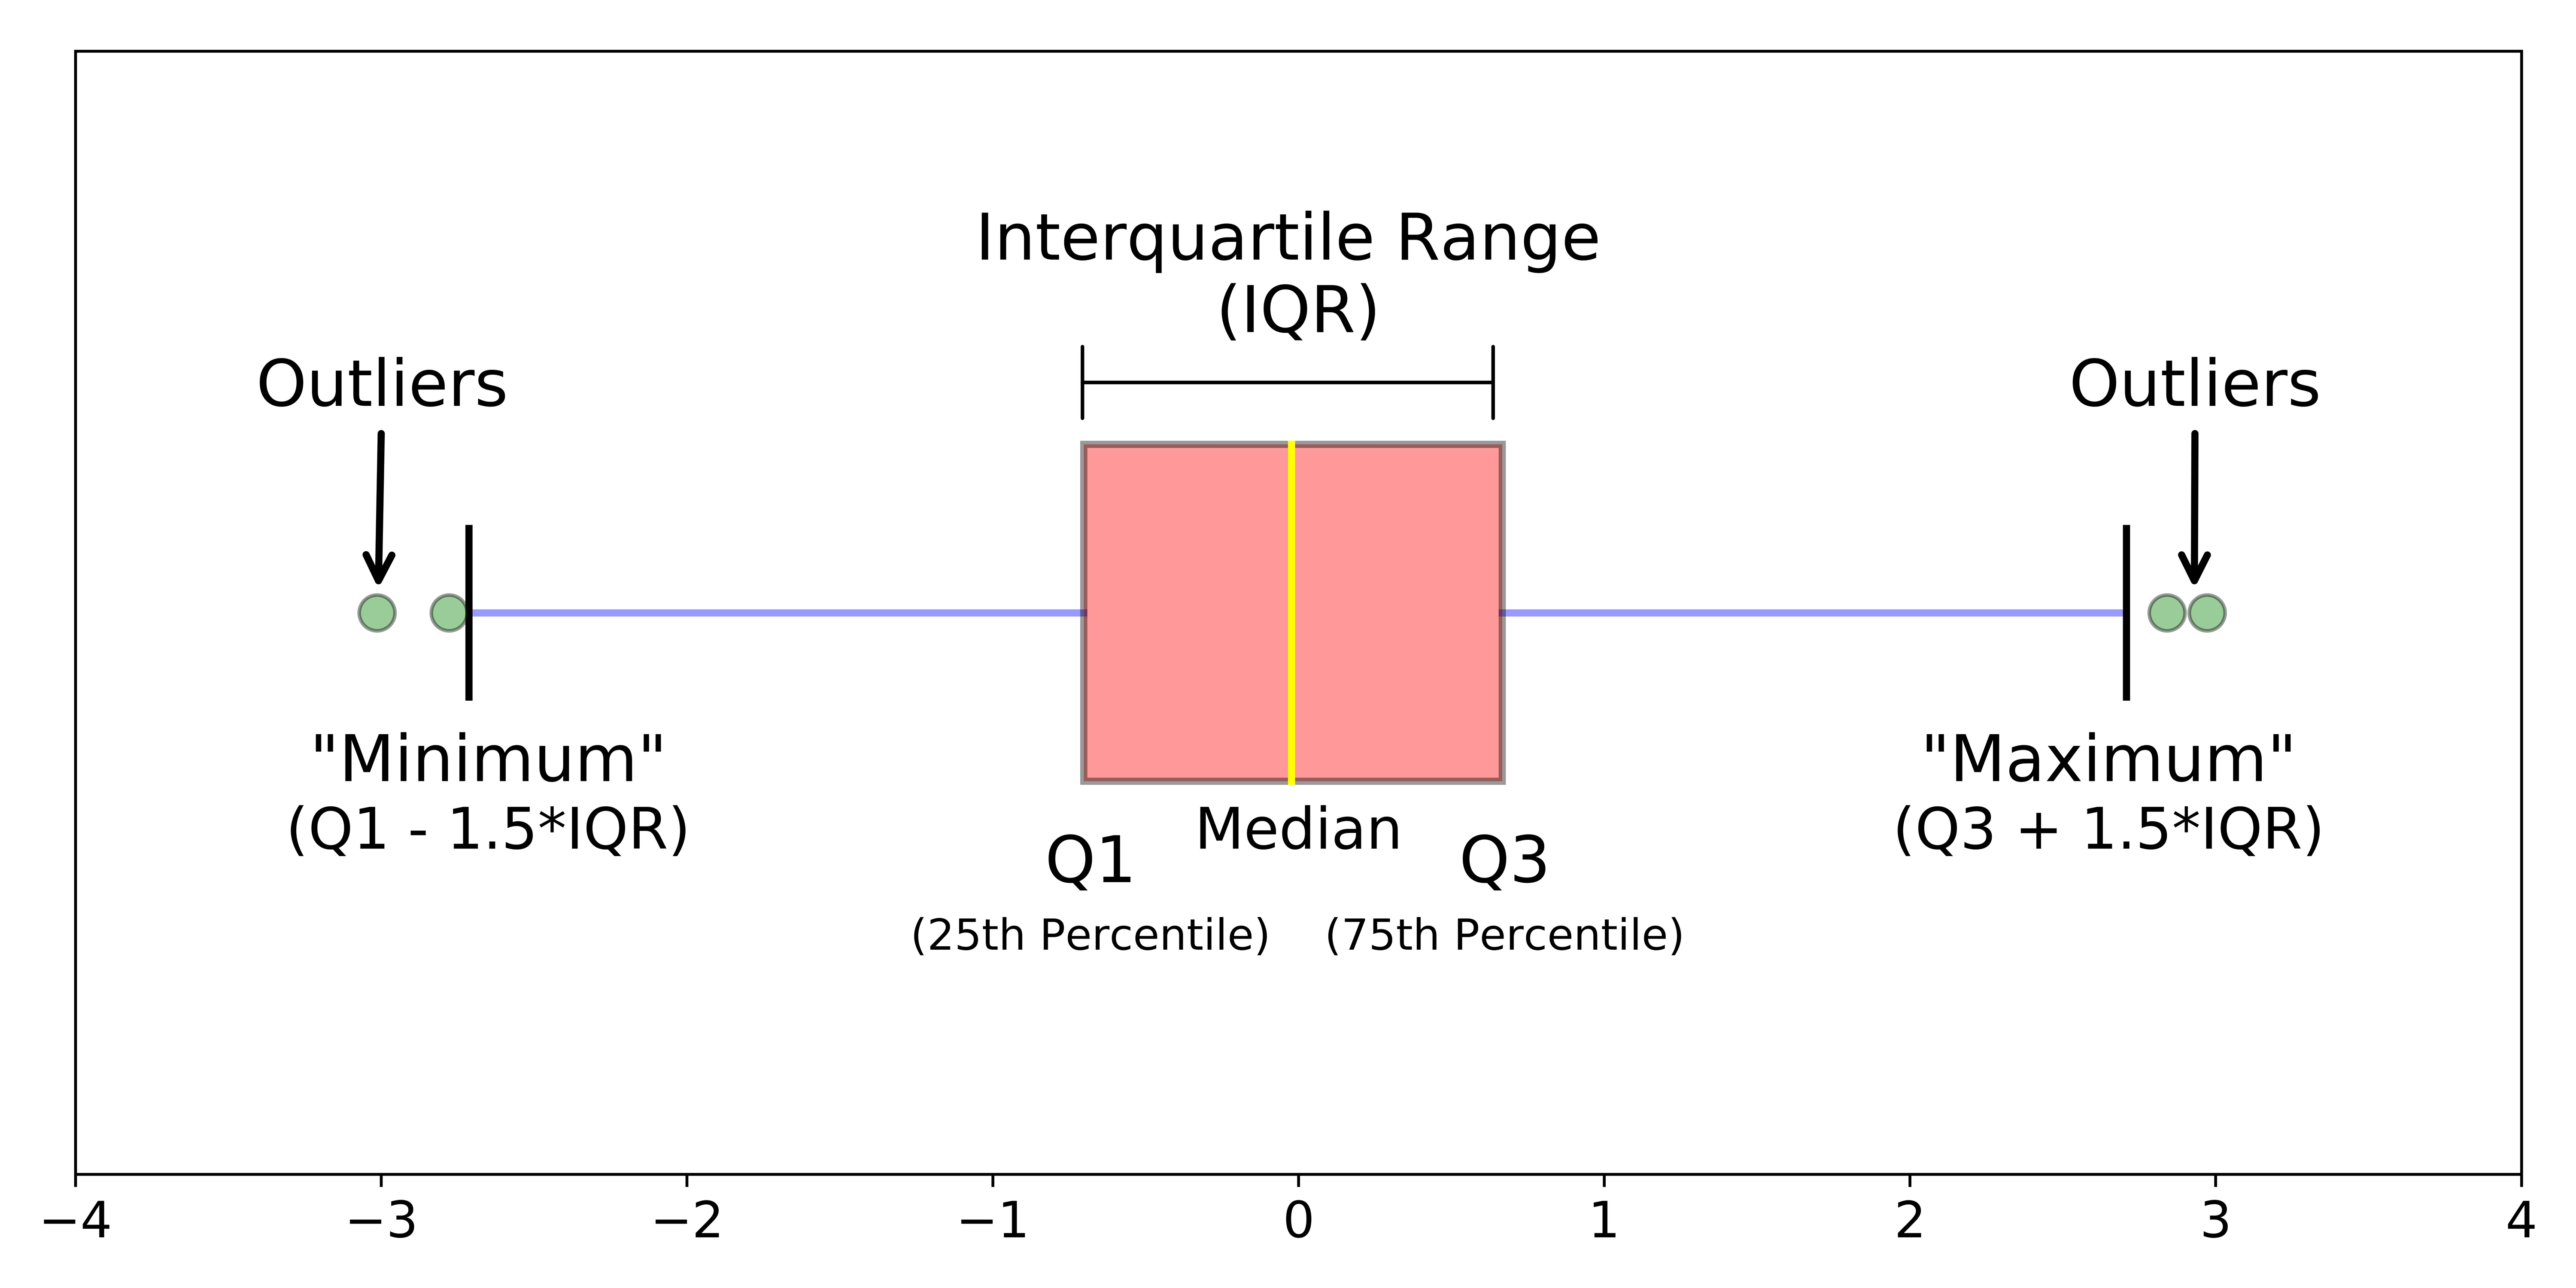

In [ ]:
# Image("../fig/boxplot.jpg")

In [26]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# 좌석 등급(Pclass)별 운임(Fare) 데이터를 리스트로 분리
# plt.boxplot()은 각 그룹별 데이터의 리스트를 입력받아야 합니다.
fare_p1 = titanic[titanic['pclass'] == 1]['fare'].dropna()
fare_p2 = titanic[titanic['pclass'] == 2]['fare'].dropna()
fare_p3 = titanic[titanic['pclass'] == 3]['fare'].dropna()

# boxplot에 전달할 데이터 리스트와 레이블 리스트 준비
plot_data = [fare_p1, fare_p2, fare_p3]
plot_labels = ['1st Class', '2nd Class', '3rd Class']

plt.figure(figsize=(8, 6))

# plt.boxplot()을 사용하여 상자 그림 생성
plt.boxplot(
    plot_data,
    tick_labels=plot_labels, # 3.9 이전 버전에서는 labels 사용했으나, 지금은 tick_labels로 변경
    patch_artist=True,  # 상자를 색칠
    # medianprops={'color': 'red'}, # 중앙값 선 색상
    # flierprops={'marker': 'o', 'markerfacecolor': 'blue', 'alpha': 0.5} # 이상치 스타일
)

plt.title('Fare Distribution by Passenger Class (Box Plot)')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.grid(axis='y', linestyle='--')
plt.show()


'''  
그래프 해석
Box Plot은 데이터의 5가지 요약 통계량(Five-Number Summary)을 보여줍니다: 최소값, 1사분위수(Q1), 
중앙값(Q2/Median), 3사분위수(Q3), 최대값, 그리고 이상치.

중심 경향 (중앙값 - 빨간 선):
1st Class의 중앙값(Median)이 $60 이상으로 가장 높습니다.
2nd Class는 약 $14 정도로 중간입니다.
3rd Class는 약 $8 미만으로 중앙값이 가장 낮습니다. 좌석 등급이 낮을수록 운임의 중앙값이 급격히 낮아지는 
명확한 경향을 보여줍니다.

퍼짐 정도 (IQR - 상자의 길이):
1st Class의 상자(IQR, Q1부터 Q3까지) 길이가 가장 길어, 운임의 변동성(분산)이 가장 큽니다.
2nd Class와 3rd Class는 상자 길이가 상대적으로 짧아, 운임이 좁은 범위에 집중되어 있음을 알 수 있습니다.

이상치 (Outliers - 파란 점):
1st Class에서 운임이 높은 곳에 파란색 점이 다수 보입니다. 이는 다른 승객들에 비해 훨씬 높은 운임(수백 달러) 을 지불한 승객(즉, 부유층)이 존재함을 명확히 보여주는 이상치(Outlier)입니다.
2nd Class와 3rd Class에도 소수의 이상치가 있지만, 1st Class만큼 그 값이 극단적이지는 않습니다.
'''

### 막대 그래프 (범주형 데이터 비교) (.bar())

C:\Users\nbumk\AppData\Local\Temp\ipykernel_11956\1813442060.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip_by_day = tips.groupby('day')['tip'].mean().sort_values(ascending=False)


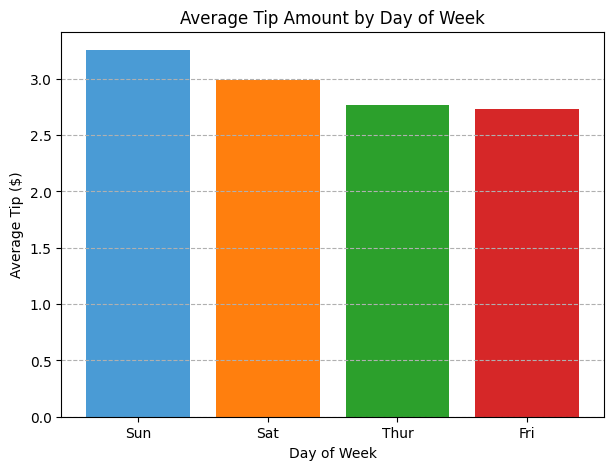

'    \n이 그래프는 토요일(Sat)의 평균 팁 금액이 가장 높고, 목요일(Thur)과 일요일(Sun)이 그 뒤를 이으며, \n금요일(Fri)이 가장 낮음을 보여줍니다. 이는 주말에 손님들이 더 많은 금액을 지불하거나 관대하게 팁을 \n주는 경향이 있음을 시사합니다.\n'

In [ ]:
# 요일별 평균 팁 계산
avg_tip_by_day = tips.groupby('day')['tip'].mean().sort_values(ascending=False)
# avg_tip_by_day = tips.groupby('day', observed=True)['tip'].mean().sort_values(ascending=False) #observed 기본 값은 사장될 예정 
avg_tip_by_day
plt.figure(figsize=(7, 5))
plt.bar(avg_tip_by_day.index, avg_tip_by_day, 
    color=["#4a9bd5", '#ff7f0e', '#2ca02c', '#d62728'], # 각 막대 색상 지정
)
plt.title('Average Tip Amount by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Tip ($)')
plt.grid(axis='y', linestyle='--')
plt.show()

'''    
이 그래프는 토요일(Sat)의 평균 팁 금액이 가장 높고, 목요일(Thur)과 일요일(Sun)이 그 뒤를 이으며, 
금요일(Fri)이 가장 낮음을 보여줍니다. 이는 주말에 손님들이 더 많은 금액을 지불하거나 관대하게 팁을 
주는 경향이 있음을 시사합니다.
'''

### 파이 그래프 (전체 대비 비율) (.pie())
**파이차트는 별도 라이브러리를 import 해서 사용하는 것을 추천**

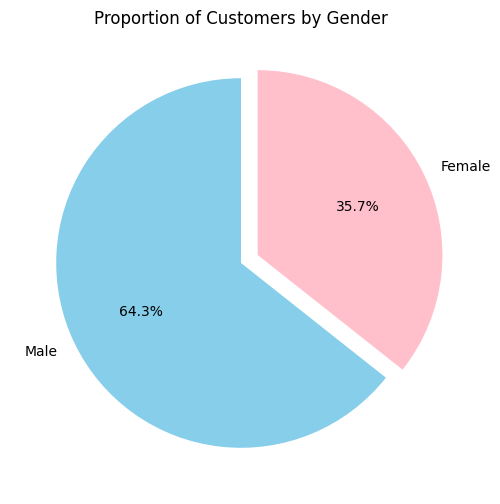

'    \n그래프에 따르면, 남성(Male) 손님이 전체의 약 64.3%를 차지하고, \n여성(Female) 손님은 약 35.7%를 차지합니다. \n이 데이터셋에서는 남성 손님의 수가 여성 손님 수보다 약 2배 가까이 많다는 것을 시각적으로 즉시 파악할 수 있습니다.\n'

In [29]:
# 성별 손님 수 계산
gender_counts = tips['sex'].value_counts()

plt.figure(figsize=(6, 6))
gender_counts.plot.pie(
    autopct='%1.1f%%', # 소수점 첫째 자리까지 비율 표시
    startangle=90,
    colors=['skyblue', 'pink'],
    explode=[0, 0.1] # Female 쪽을 약간 분리하여 강조
)
plt.title('Proportion of Customers by Gender')
plt.ylabel('') # y축 레이블(sex) 제거
plt.show()

'''    
그래프에 따르면, 남성(Male) 손님이 전체의 약 64.3%를 차지하고, 
여성(Female) 손님은 약 35.7%를 차지합니다. 
이 데이터셋에서는 남성 손님의 수가 여성 손님 수보다 약 2배 가까이 많다는 것을 시각적으로 즉시 파악할 수 있습니다.
'''

## 2. seaborn을 이용한 시각화
-
    - `sns.histplot()`: 연속형 데이터의 빈도 분포, 데이터의 중심, 분산, 이상치 확인에 필수
    - `sns.boxplot()/violinplot()`: 그룹별 분포, 사분위수, 이상치, 여러 그룹의 분포를 비교할 때 필수
    - `sns.barplot()`: 연속향 데이터의 평균 또는 중앙값과 표준편차를 나타냄
    - `sns.regplot(), sns.lmplot()`: 두 변수의 선형 관계와 신뢰구간을 동시에 보여줌
    - `sns.scatterplot()`: 두 변수 사이의 상관관계, 패턴 확인

## penguins data

- 데이터 출처: 남극의 팔머 군도(Palmer Archipelago)에 사는 펭귄들을 조사하여 수집한 데이터입니다.
- 데이터 크기: 345마리의 펭귄에 대한 정보를 포함하고 있습니다.
- 결측치: 성별, 부리 길이, 몸무게 등 일부 열에 결측값이 포함되어 있어, 결측값 처리 방법을 학습하는 데 유용합니다.

    - `species`: 펭귄의 종을 나타내는 범주형 데이터. Adelie, Chinstrap, Gentoo 세 종류
    - `island`: 펭귄이 관측된 섬의 이름. Biscoe, Dream, Torgersen 세 섬
    - `bill_length_mm`: 펭귄 부리의 길이(밀리미터)를 나타내는 수치형 데이터
    - `bill_depth_mm`: 펭귄 부리의 깊이(두께, 밀리미터)를 나타내는 수치형 데이터
    - `flipper_length_mm`: 펭귄 날개(지느러미)의 길이(밀리미터)를 나타내는 수치형 데이터
    - `body_mass_g`: 펭귄의 몸무게(그램)를 나타내는 수치형 데이터
    - `sex`: 펭귄의 성별(수컷 또는 암컷)을 나타내는 범주형 데이터 

### 연속형 데이터의 분포 시각화: sns.histplot()
- `단일 연속형 변수 분포`:	sns.histplot(data=penguins, x="bill_length_mm")
- `커널 밀도 추정선(KDE) 추가`:	sns.histplot(data=penguins, x="flipper_length_mm", **kde=True**)
- `범주별 분포 비교`: 	sns.histplot(data=penguins, x="body_mass_g",**hue="species"**)

In [41]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


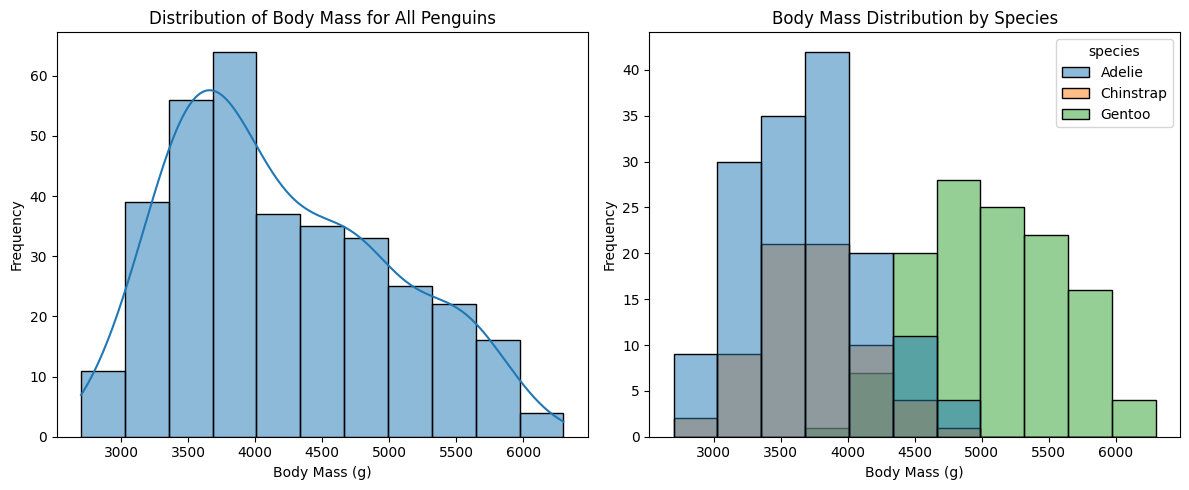

In [42]:
plt.figure(figsize=(12, 5))

# Check body mass distribution (with KDE)
plt.subplot(1, 2, 1)
sns.histplot(data=penguins, x="body_mass_g", kde=True)
plt.title("Distribution of Body Mass for All Penguins")
plt.xlabel("Body Mass (g)")
plt.ylabel("Frequency")


# Compare body mass distribution by species (adjust transparency)
plt.subplot(1, 2, 2)
sns.histplot(data=penguins, x="body_mass_g", hue="species", alpha=0.5)
plt.title("Body Mass Distribution by Species")
plt.xlabel("Body Mass (g)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### <sns.histplot() 문제>
- `Penguins` 자료에서 "flipper_length_mm" 에 대한 히스토그램을 species 별로 density estimate 라인과 같이 그려 보시오.

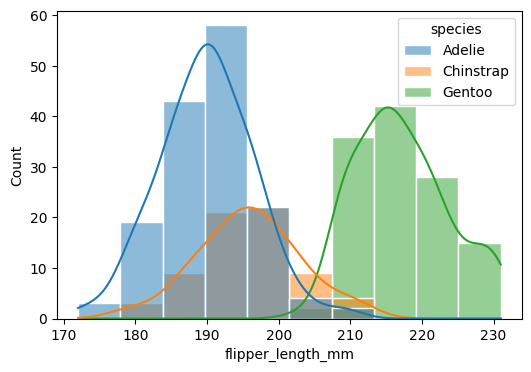

In [43]:
# < 풀이 >

## Add a kernel density estimate to smooth the histogram

fig, axs = plt.subplots(figsize = (6,4))

sns.histplot(data=penguins, 
             x ="flipper_length_mm", 
             alpha = 0.5,
             kde=True,
             hue = "species",
             edgecolor = "w" )

plt.show()

### 연속형 데이터의 추정치 시각화: sns.barplot()

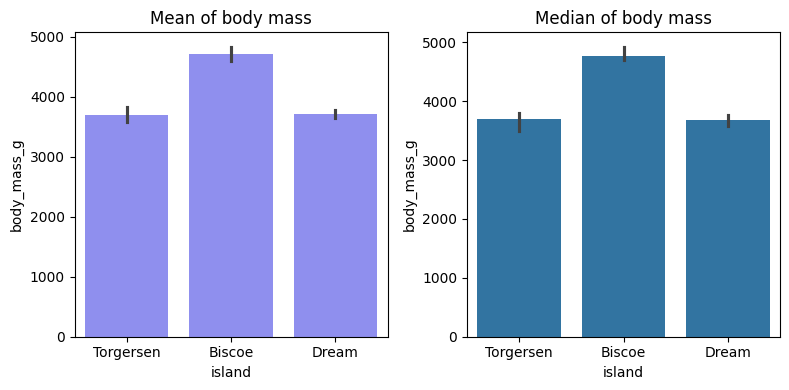

In [44]:
## estimator = 'mean'/'median'

fig, axs = plt.subplots(1, 2, figsize = (8, 4))
sns.barplot(penguins, 
            x="island", 
            y="body_mass_g", 
            estimator='mean', 
            color = 'b', 
            ax = axs[0], 
            alpha = 0.5)
axs[0].set_title("Mean of body mass")

sns.barplot(penguins, 
            x="island", 
            y="body_mass_g", 
            estimator='median', 
            ax = axs[1])
axs[1].set_title("Median of body mass")

plt.tight_layout()
plt.show()

### 그룹별 분포 비교
- `sns.boxplot()`: 사분위수와 이상치 확인
- `sns.violinplot()`: 상세 분포 형태 확인

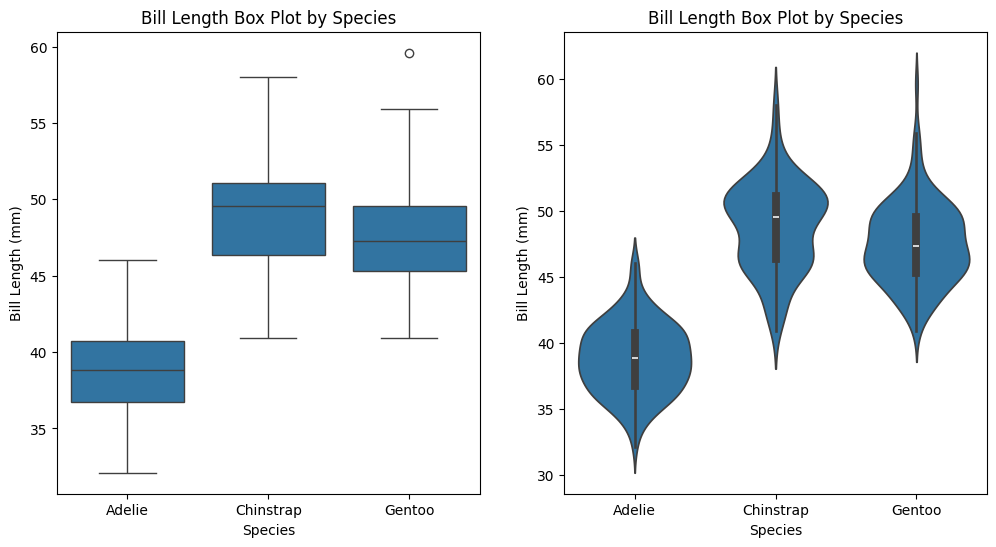

In [45]:
plt.figure(figsize = (12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=penguins, x="species", y="bill_length_mm")
plt.title("Bill Length Box Plot by Species")
plt.xlabel("Species")
plt.ylabel("Bill Length (mm)")


plt.subplot(1, 2, 2)
sns.violinplot(data=penguins, x="species", y="bill_length_mm")
plt.title("Bill Length Box Plot by Species")
plt.xlabel("Species")
plt.ylabel("Bill Length (mm)")

plt.show()

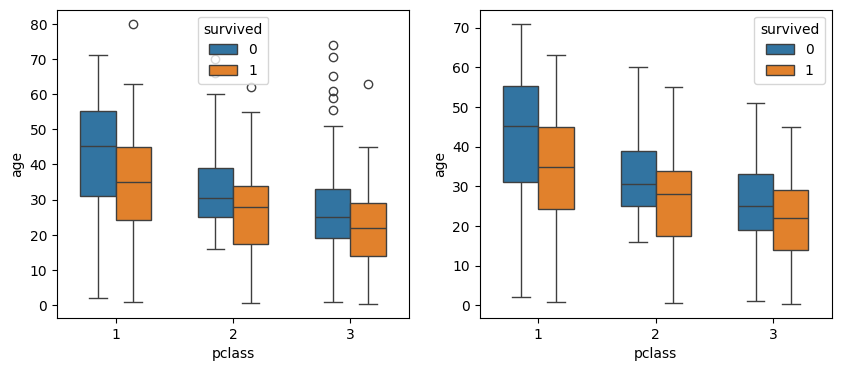

In [47]:
## Draw a vertical boxplot with nested grouping by two variables
titanic = sns.load_dataset("titanic")

plt.figure(figsize = (10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data=titanic, x="pclass", y="age", hue="survived", width = 0.6)
plt.subplot(1, 2, 2)
sns.boxplot(data=titanic, x="pclass", y="age", hue="survived", width = 0.6, showfliers=False)

plt.show()

### 선형 관계 : sns.regplot()

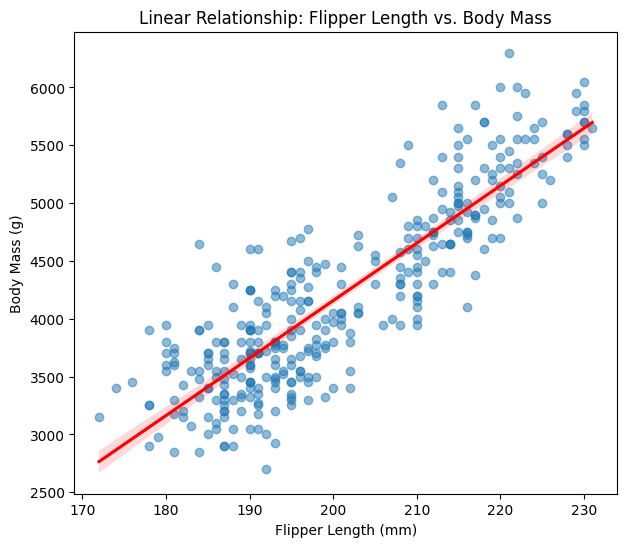

In [ ]:
penguins = sns.load_dataset("penguins")

plt.figure(figsize=(7, 6))
sns.regplot(
    data=penguins,
    x="flipper_length_mm",
    y="body_mass_g",
    marker = "o",
    fit_reg=True,
    line_kws={"color": "red"}, # 회귀선 색상 지정
    scatter_kws={"alpha": 0.5}, # 산점도 투명도 지정
)
plt.title("Linear Relationship: Flipper Length vs. Body Mass")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Body Mass (g)")
plt.show()

# 종류별 선형 관계 분석이 필요하면 lmplot 이용

### 선형 관계 : sns.lmplot()

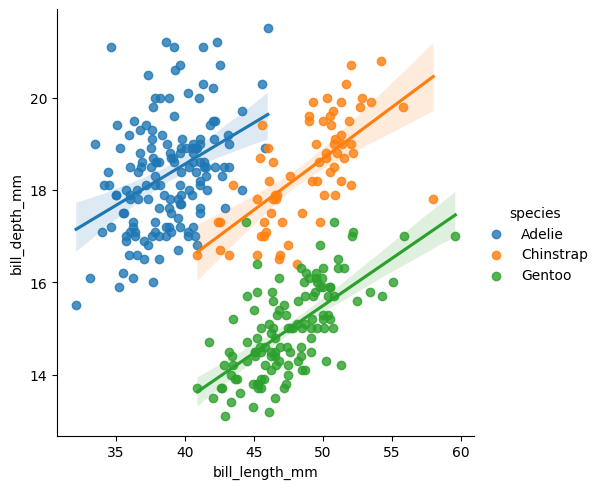

In [ ]:
## regression by category

sns.lmplot(
           x="bill_length_mm",
           y="bill_depth_mm",
           data=penguins,
           hue="species")
plt.show()

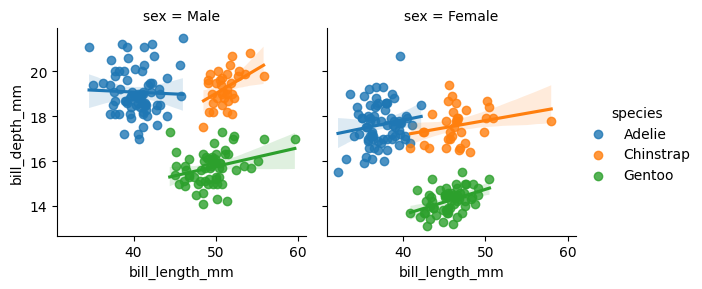

In [51]:
## regression by columns

sns.lmplot(x="bill_length_mm",
           y="bill_depth_mm",
           data=penguins,
           hue="species", 
           col="sex", 
           height=3)
plt.show()

### 두 변수 간의 관계 시각화: sns.scatterplot()
- `기본 관계 시각화`:	        sns.scatterplot(data=penguins, x="bill_length_mm", y="bill_depth_mm")
- `범주형 변수 추가 (색상)`:	sns.scatterplot(data=penguins, x="bill_length_mm", y="flipper_length_mm", hue="species")
- `연속형 변수 추가 (크기)`:	sns.scatterplot(data=penguins, x="bill_length_mm", y="body_mass_g", size="flipper_length_mm")

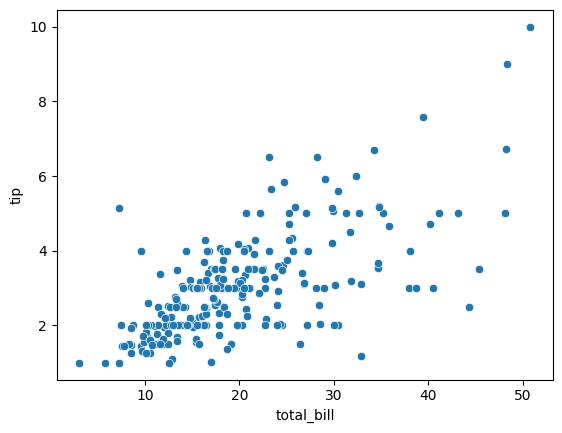

In [52]:
tips = sns.load_dataset("tips")

sns.scatterplot(
    x="total_bill",
    y="tip",
    data=tips)
plt.show()

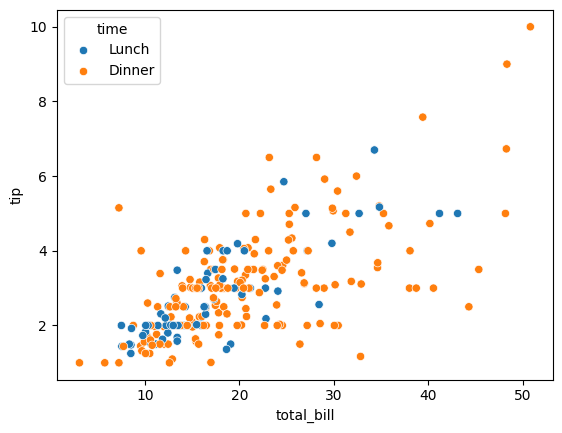

In [53]:
## hue
sns.scatterplot(
    x="total_bill",
    y="tip",
    data=tips,
    hue="time")

plt.show()

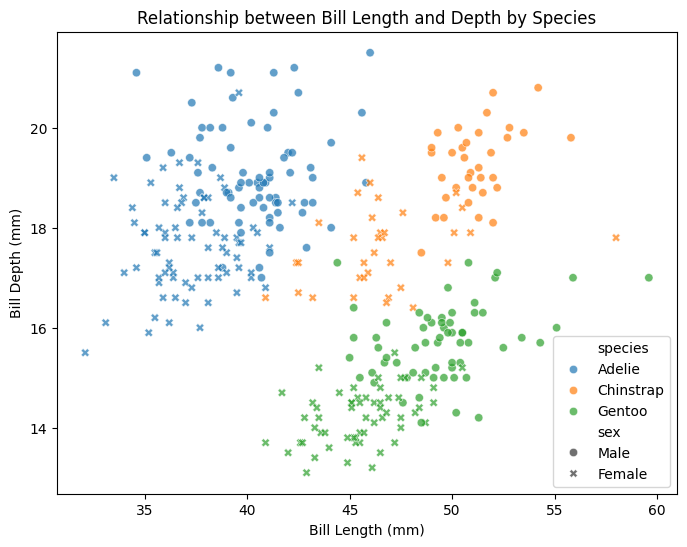

In [54]:
## style
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",  # 종별 색상 구분
    style="sex",    # 성별 모양 구분
    # size="body_mass_g", # 몸무게 크기 반영
    alpha=0.7,
    sizes=(20, 100)
)
plt.title("Relationship between Bill Length and Depth by Species")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
# plt.legend(title='Species/Sex/Body Mass', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()